# Monday.com — VIP Consulting Assignment EDA

**Goal:** Binary classification (`is_suitable`) — identify which accounts should receive VIP consulting services, decided within the first two weeks from registration.

**Datasets:**
- `accounts.csv` (~106 MB) — one row per account, contains target `is_suitable`
- `users.csv` (~156 MB) — one row per user, many users per account
- `events.csv` (~565 MB) — daily aggregated event counts per user

**This notebook covers:**
1. Loading & schema overview for all three datasets
2. Missing value audit
3. Target distribution (`is_suitable`)
4. Account-level feature exploration
5. User-level feature exploration (aggregated to account level)
6. Event-level usage patterns (chunked aggregation)
7. Temporal patterns
8. Correlation heatmap with target
9. Key EDA findings and feature engineering ideas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)

DATA_DIR = os.path.join('..', 'resources')
print(f'Data directory: {os.path.abspath(DATA_DIR)}')

Data directory: e:\development\monday\resources


## 1. Load Datasets

In [2]:
acc = pd.read_csv(
    os.path.join(DATA_DIR, 'accounts.csv'),
    parse_dates=['created_at', 'trial_start', 'churn_date', 'subscription_started_at'],
    dayfirst=True,
    low_memory=False
)
acc.replace({'NA': np.nan, 'na': np.nan, '': np.nan}, inplace=True)
acc['is_suitable'] = pd.to_numeric(acc['is_suitable'], errors='coerce')
acc['paying']      = pd.to_numeric(acc['paying'],      errors='coerce')
acc['mrr']         = pd.to_numeric(acc['mrr'],         errors='coerce')
acc['collection_21_days'] = pd.to_numeric(acc['collection_21_days'], errors='coerce')

# Derive temporal account-level features early so they're available for the joined df
acc['created_at'] = pd.to_datetime(acc['created_at'], errors='coerce')
acc['subscription_started_at'] = pd.to_datetime(acc['subscription_started_at'], errors='coerce')
acc['days_to_subscription'] = (acc['subscription_started_at'] - acc['created_at']).dt.days
acc['cohort_month'] = acc['created_at'].dt.to_period('M')
acc['churned'] = acc['churn_date'].notna().astype(int)

# Clean Excel-mangled team_size values (e.g. '02-May' = '2-5')
ts_map = {'01-Jan':'1','02-May':'2-5','06-Oct':'6-10'}
acc['team_size_clean'] = acc['team_size'].map(ts_map).fillna(acc['team_size'])

print(f'Accounts: {acc.shape[0]:,} rows x {acc.shape[1]} cols')

Accounts: 716,830 rows x 32 cols


In [3]:
usr = pd.read_csv(
    os.path.join(DATA_DIR, 'users.csv'),
    parse_dates=['created_at', 'became_active_at'],
    low_memory=False
)
usr.replace({'NA': np.nan, 'na': np.nan, '': np.nan}, inplace=True)
for col in ['is_admin', 'pending', 'enabled', 'has_photo', 'has_phone', 'serial_number']:
    usr[col] = pd.to_numeric(usr[col], errors='coerce')

print(f'Users:    {usr.shape[0]:,} rows x {usr.shape[1]} cols')

Users:    1,123,343 rows x 21 cols


In [4]:
# Events are 565 MB — read in chunks and aggregate to account level to stay within RAM
CHUNK = 500_000
event_path = os.path.join(DATA_DIR, 'events.csv')

agg_cols = [
    'total_events','column_events','board_events','content_events',
    'group_events','invite_events','import_events','notification_events',
    'new_entry_events','payment_events','inbox_events',
    'communicating_events','non_communicating_events',
    'web_events','ios_events','android_events','desktop_app_events',
    'empty_events','num_of_boards','count_kind_columns'
]

parts = []
for chunk in pd.read_csv(event_path, chunksize=CHUNK, parse_dates=['date'], low_memory=False):
    chunk.replace({'NA': np.nan}, inplace=True)
    for c in agg_cols:
        chunk[c] = pd.to_numeric(chunk[c], errors='coerce')
    grp = chunk.groupby('account_id')[agg_cols].sum()
    grp['active_users'] = chunk.groupby('account_id')['user_id'].nunique()
    grp['active_days']  = chunk.groupby('account_id')['date'].nunique()
    parts.append(grp)

evt_agg = pd.concat(parts).groupby('account_id').sum()
print(f'Events aggregated: {evt_agg.shape[0]:,} accounts x {evt_agg.shape[1]} feature cols')

Events aggregated: 716,628 accounts x 22 feature cols


In [5]:
# Aggregate user-level features to account level (must happen before joining)
usr['time_to_activate_min'] = (
    usr['became_active_at'] - usr['created_at']
).dt.total_seconds() / 60

usr_agg = usr.groupby('account_id').agg(
    n_users           = ('user_id',              'count'),
    admin_ratio       = ('is_admin',             'mean'),
    pending_ratio     = ('pending',              'mean'),
    enabled_ratio     = ('enabled',              'mean'),
    has_photo_ratio   = ('has_photo',            'mean'),
    has_phone_ratio   = ('has_phone',            'mean'),
    median_admin_tta  = ('time_to_activate_min', lambda x: x[usr.loc[x.index,'is_admin']==1].median()),
).reset_index()

# simpler: separate median for admins only
admin_tta = (
    usr[usr['is_admin'] == 1]
    .groupby('account_id')['time_to_activate_min']
    .median()
    .rename('median_admin_tta_min')
)

usr_agg2 = usr.groupby('account_id').agg(
    n_users         = ('user_id',    'count'),
    admin_ratio     = ('is_admin',   'mean'),
    pending_ratio   = ('pending',    'mean'),
    enabled_ratio   = ('enabled',    'mean'),
    has_photo_ratio = ('has_photo',  'mean'),
    has_phone_ratio = ('has_phone',  'mean'),
).reset_index()
usr_agg2 = usr_agg2.merge(admin_tta.reset_index(), on='account_id', how='left')

print(f'User aggregates: {usr_agg2.shape}')

User aggregates: (716099, 8)


In [6]:
# Build master account-level dataframe (all features available before modeling)
master = (
    acc
    .merge(usr_agg2,           on='account_id', how='left')
    .merge(evt_agg.reset_index(), on='account_id', how='left')
)

# Derived engagement features
master['events_per_active_day'] = master['total_events'] / (master['active_days'] + 1)
master['user_adoption_rate']    = master['active_users'] / (master['n_users'] + 1)
master['collab_events']         = master['invite_events'] + master['communicating_events']

# Platform shares
platform_cols = ['web_events','ios_events','android_events','desktop_app_events']
for col in platform_cols:
    master[col] = pd.to_numeric(master[col], errors='coerce').fillna(0)
master['total_platform'] = master[platform_cols].sum(axis=1)
for col in platform_cols:
    master[f'{col}_share'] = master[col] / (master['total_platform'] + 1)

print(f'Master dataframe: {master.shape}')
print(f'Target coverage: {master["is_suitable"].notna().sum():,} accounts have a label')

Master dataframe: (716830, 69)
Target coverage: 716,830 accounts have a label


## 2. Schema Overview

In [7]:
print('=== ACCOUNTS (first 3 rows) ===')
display(acc[['account_id','account_name','created_at','plan_id','paying','mrr',
             'industry','team_size','country','is_suitable']].head(3))

print('\n=== USERS (first 3 rows) ===')
display(usr[['account_id','user_id','created_at','is_admin','seniority',
             'device','os','country','has_photo','has_phone']].head(3))

=== ACCOUNTS (first 3 rows) ===


,account_id,account_name,created_at,plan_id,paying,mrr,industry,team_size,country,is_suitable
0,235592,"Lopez, Evans and Mitchell",2019-01-29 10:24:00,NaN,0,NaN,Creative,02-May,BR,0
1,1240640,"Berger, Roberts and Martin",2019-06-05 20:19:00,NaN,0,NaN,NaN,02-May,ZA,0
2,553815,Burns-Long,2019-03-03 10:28:00,NaN,0,NaN,NaN,NaN,BR,0



=== USERS (first 3 rows) ===


,account_id,user_id,created_at,is_admin,seniority,device,os,country,has_photo,has_phone
0,4,5,2019-01-01 00:02:56,1,NaN,mobile,android,IL,1,1
1,6,7,2019-01-01 00:01:53,1,NaN,desktop,mac,US,1,1
2,7,8,2019-01-01 00:02:13,1,NaN,desktop,windows,IL,1,1


## 3. Missing Value Audit

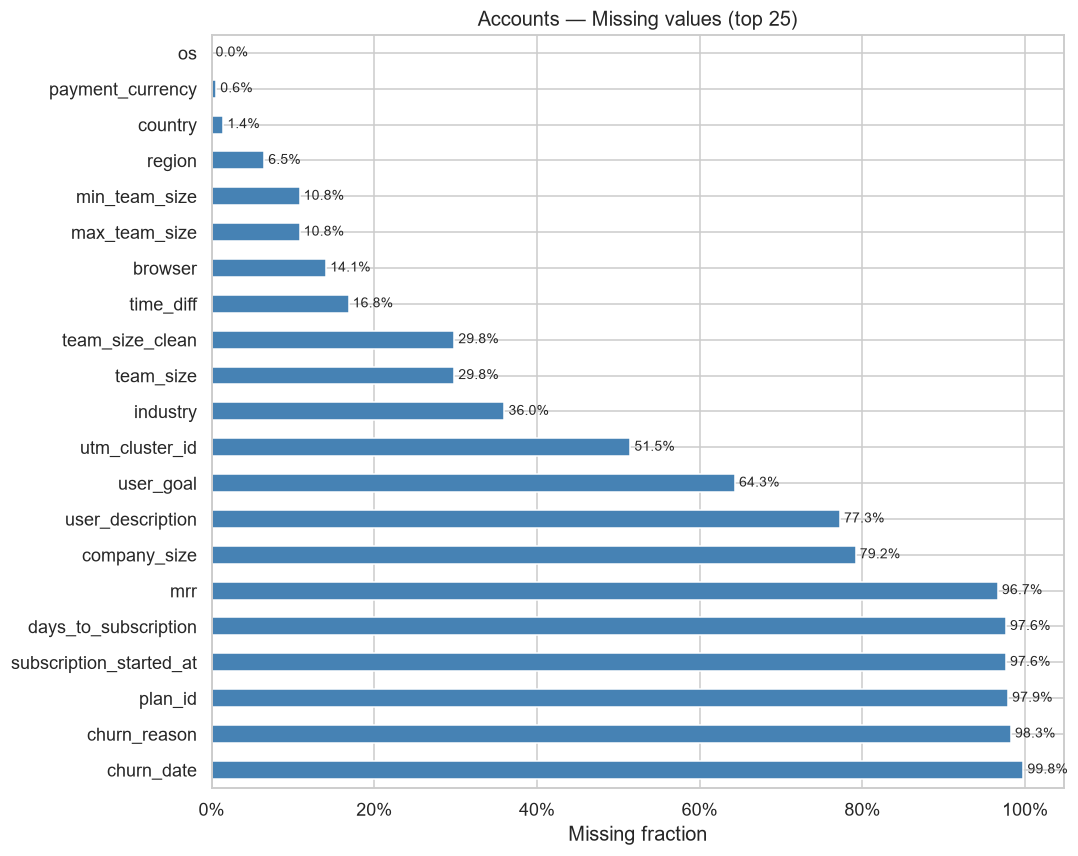

In [8]:
def missing_report(df, name, top_n=25):
    m = df.isnull().mean().sort_values(ascending=False).head(top_n)
    m = m[m > 0]
    fig, ax = plt.subplots(figsize=(10, max(3, len(m)*0.38)))
    m.plot.barh(ax=ax, color='steelblue')
    ax.set_xlabel('Missing fraction')
    ax.set_title(f'{name} — Missing values (top {top_n})')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    for p, v in zip(ax.patches, m.values):
        ax.text(v + 0.005, p.get_y() + p.get_height()/2, f'{v:.1%}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

missing_report(acc, 'Accounts')

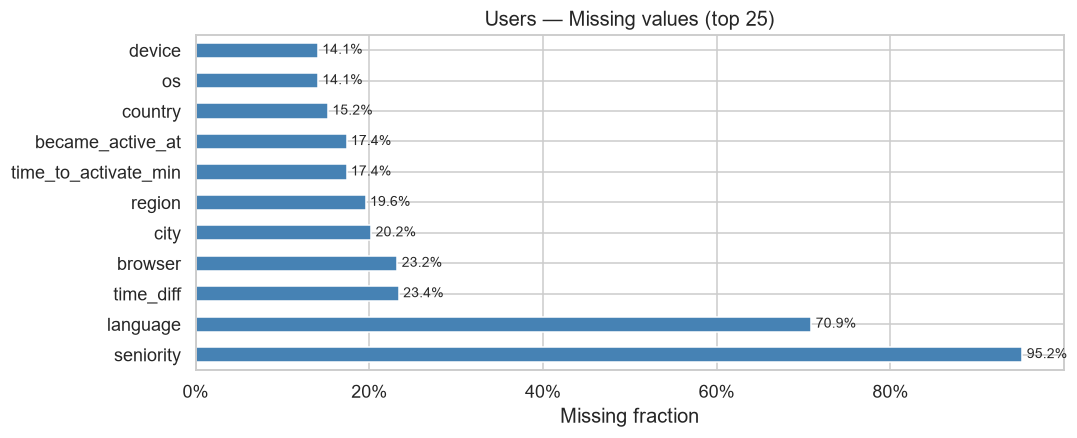

In [9]:
missing_report(usr, 'Users')

## 4. Target Variable: `is_suitable`

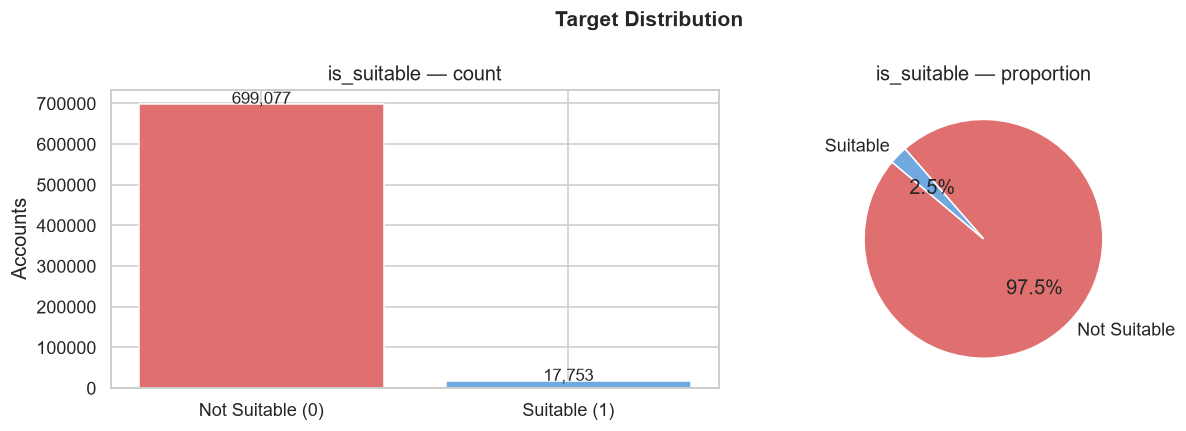

Class balance:
is_suitable
0    699077
1     17753

Missing target: 0 rows (0.0%)


In [10]:
target = acc['is_suitable'].dropna()
vc  = target.value_counts().reindex([0, 1]).fillna(0)
pct = target.value_counts(normalize=True).reindex([0, 1]).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Not Suitable (0)', 'Suitable (1)'], vc, color=['#e07070', '#70a8e0'])
for i, v in enumerate(vc):
    axes[0].text(i, v + 50, f'{v:,.0f}', ha='center', fontsize=11)
axes[0].set_title('is_suitable — count')
axes[0].set_ylabel('Accounts')

axes[1].pie(pct, labels=['Not Suitable', 'Suitable'],
            autopct='%1.1f%%', colors=['#e07070','#70a8e0'], startangle=140)
axes[1].set_title('is_suitable — proportion')

plt.suptitle('Target Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Class balance:\n{vc.to_string()}')
print(f"\nMissing target: {acc['is_suitable'].isnull().sum():,} rows ({acc['is_suitable'].isnull().mean():.1%})")

## 5. Account-Level Feature Exploration

### 5a. Paying vs Free

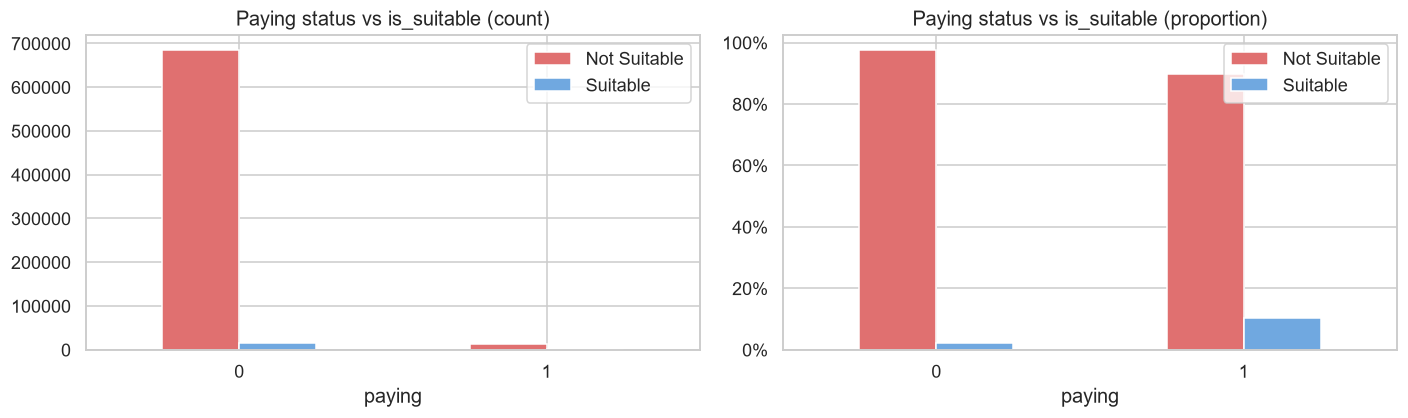

In [11]:
ct = acc.groupby(['paying', 'is_suitable']).size().unstack(fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ct.plot.bar(ax=axes[0], color=['#e07070','#70a8e0'])
axes[0].set_title('Paying status vs is_suitable (count)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Not Suitable','Suitable'])

ct_pct.plot.bar(ax=axes[1], color=['#e07070','#70a8e0'])
axes[1].set_title('Paying status vs is_suitable (proportion)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Not Suitable','Suitable'])

plt.tight_layout()
plt.show()

### 5b. Industry

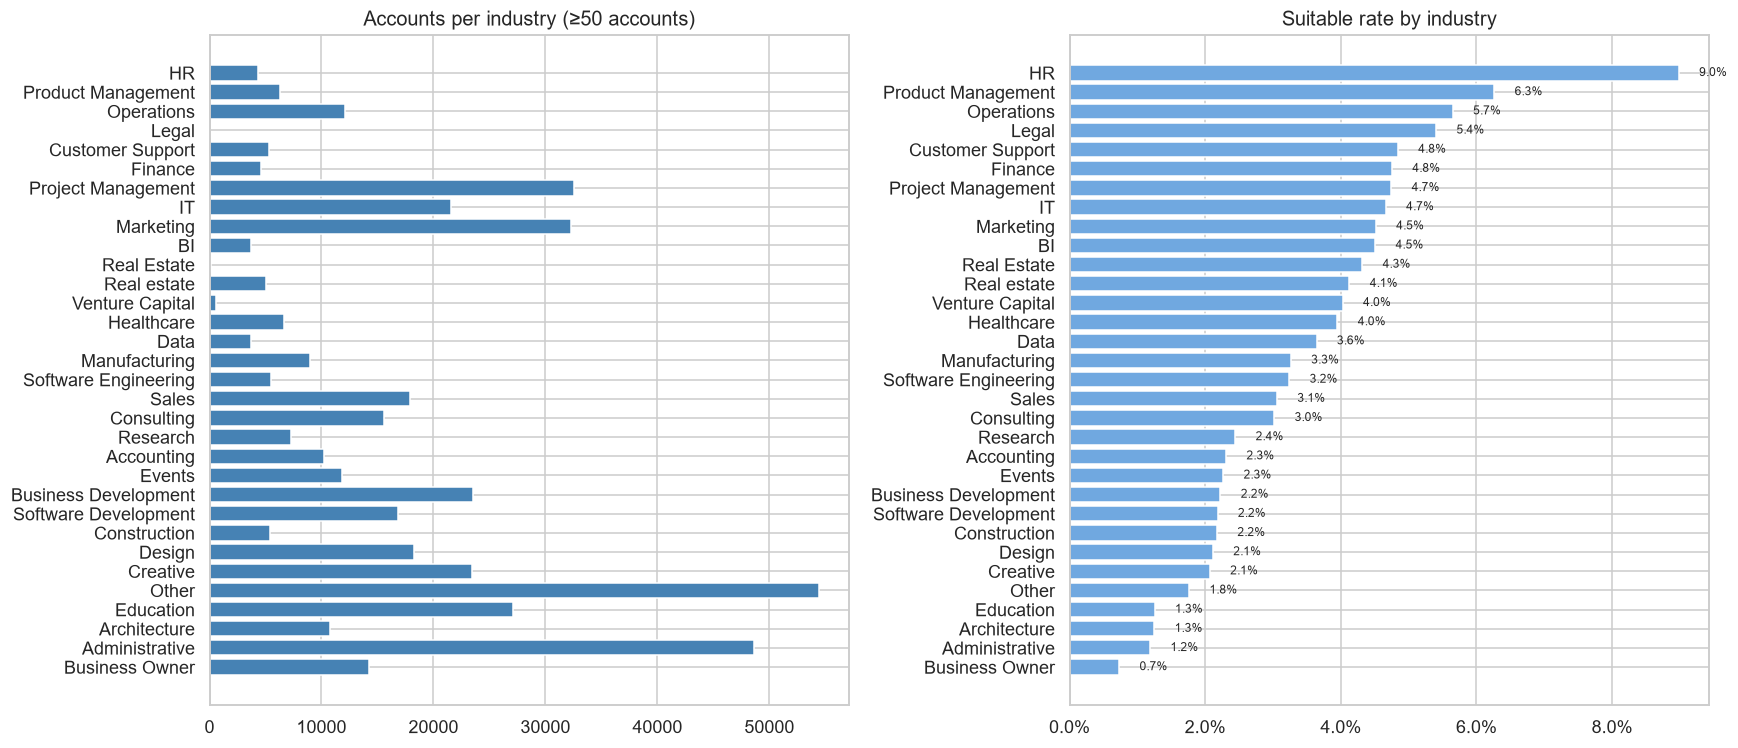

In [12]:
ind = (
    acc.groupby('industry')['is_suitable']
    .agg(['mean','count'])
    .rename(columns={'mean':'suitable_rate','count':'n'})
)
ind = ind[ind['n'] >= 50].sort_values('suitable_rate', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(ind.index, ind['n'], color='steelblue')
axes[0].set_title('Accounts per industry (≥50 accounts)')

bars = axes[1].barh(ind.index, ind['suitable_rate'], color='#70a8e0')
axes[1].set_title('Suitable rate by industry')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for bar, v in zip(bars, ind['suitable_rate']):
    axes[1].text(v + 0.003, bar.get_y() + bar.get_height()/2, f'{v:.1%}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 5c. Company / Team Size

> **Note:** `team_size` arrives with Excel date-parsing artefacts (`02-May` = `2–5`, `06-Oct` = `6–10`). These are cleaned via `team_size_clean`.

In [13]:
print('Raw team_size top values:');
print(acc['team_size'].value_counts().head(15))
print('\nCleaned team_size_clean top values:');
print(acc['team_size_clean'].value_counts().head(15))

Raw team_size top values:
team_size
02-May            185423
01-Jan            159511
06-Oct             76667
Nov-15             27887
16-25              20792
26-50              14049
51-100              7195
500                 5562
101-500             4011
1                   1320
Solo yo              350
Moi uniquement        88
Apenas eu             57
Nur ich               26
0                      8
Name: count, dtype: int64

Cleaned team_size_clean top values:
team_size_clean
2-5               185423
1                 160831
6-10               76667
Nov-15             27887
16-25              20792
26-50              14049
51-100              7195
500                 5562
101-500             4011
Solo yo              350
Moi uniquement        88
Apenas eu             57
Nur ich               26
0                      8
2                      6
Name: count, dtype: int64


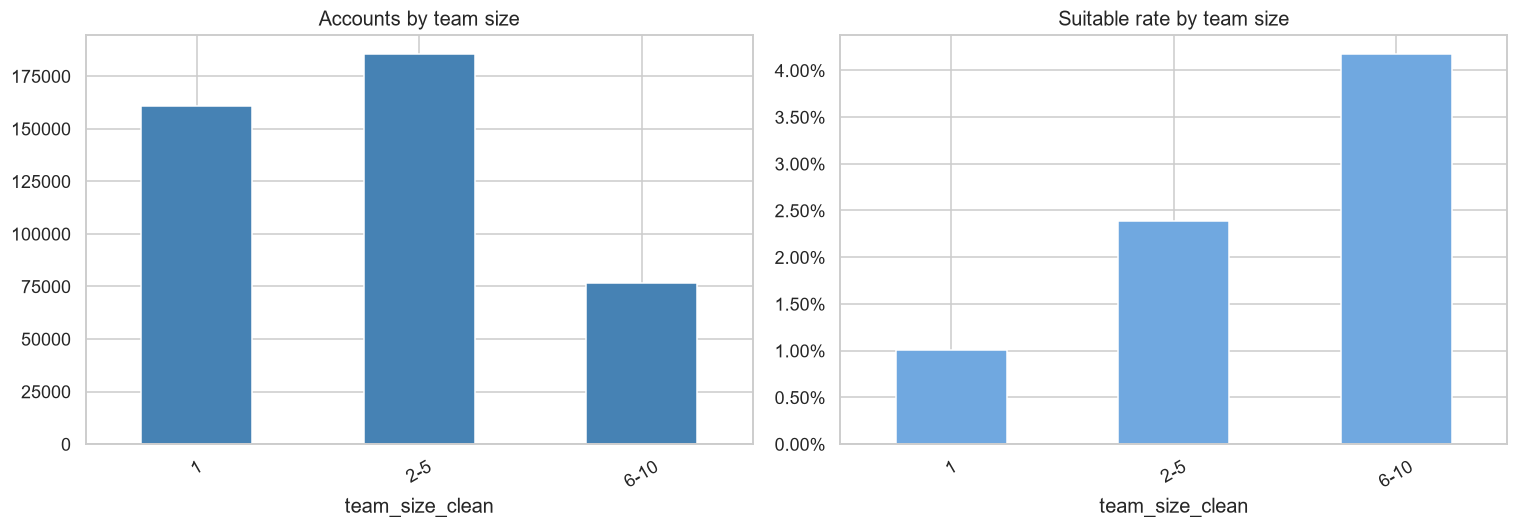

In [14]:
size_order = ['1','2-5','6-10','11-25','26-100','101-200','201+']
ts_grp = acc.groupby('team_size_clean')['is_suitable'].agg(['mean','count'])
ts_grp = ts_grp.reindex([s for s in size_order if s in ts_grp.index])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ts_grp['count'].plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Accounts by team size')
axes[0].tick_params(axis='x', rotation=30)

ts_grp['mean'].plot.bar(ax=axes[1], color='#70a8e0')
axes[1].set_title('Suitable rate by team size')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 5d. MRR & Collection in First 21 Days

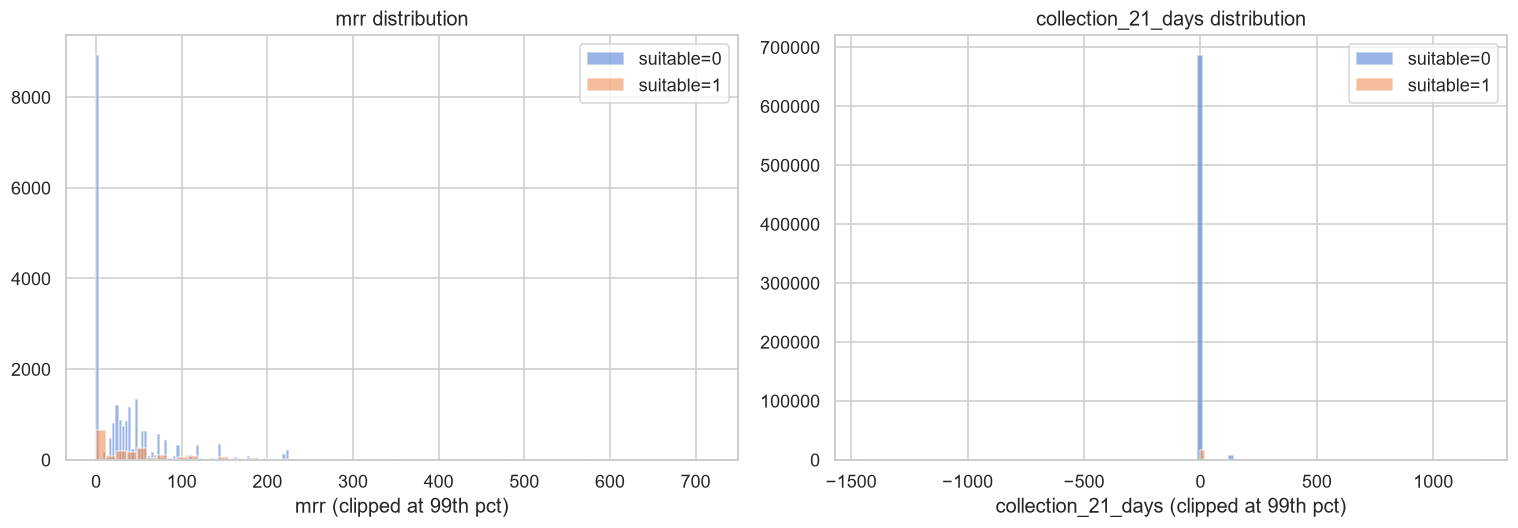

                 mrr                                             \
               count  mean    std  min  25%   50%   75%     max   
is_suitable                                                       
0            22051.0  35.5   55.4  0.0  0.0  25.0  48.0  2398.0   
1             1932.0  73.0  152.5  0.0  0.0  39.0  75.0  2630.0   

            collection_21_days                                              
                         count  mean    std     min  25%  50%  75%     max  
is_suitable                                                                 
0                     699077.0   6.8   87.0 -1440.0  0.0  0.0  0.0  7838.0  
1                      17753.0  38.1  266.8     0.0  0.0  0.0  0.0  7188.0  


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col, ax in zip(['mrr','collection_21_days'], axes):
    for label, grp in acc.dropna(subset=[col,'is_suitable']).groupby('is_suitable'):
        data = grp[col].clip(upper=grp[col].quantile(0.99))
        ax.hist(data, bins=60, alpha=0.55, label=f'suitable={int(label)}')
    ax.set_title(f'{col} distribution')
    ax.set_xlabel(f'{col} (clipped at 99th pct)')
    ax.legend()

plt.tight_layout()
plt.show()

print(acc.groupby('is_suitable')[['mrr','collection_21_days']].describe().round(1))

### 5e. Churn Analysis

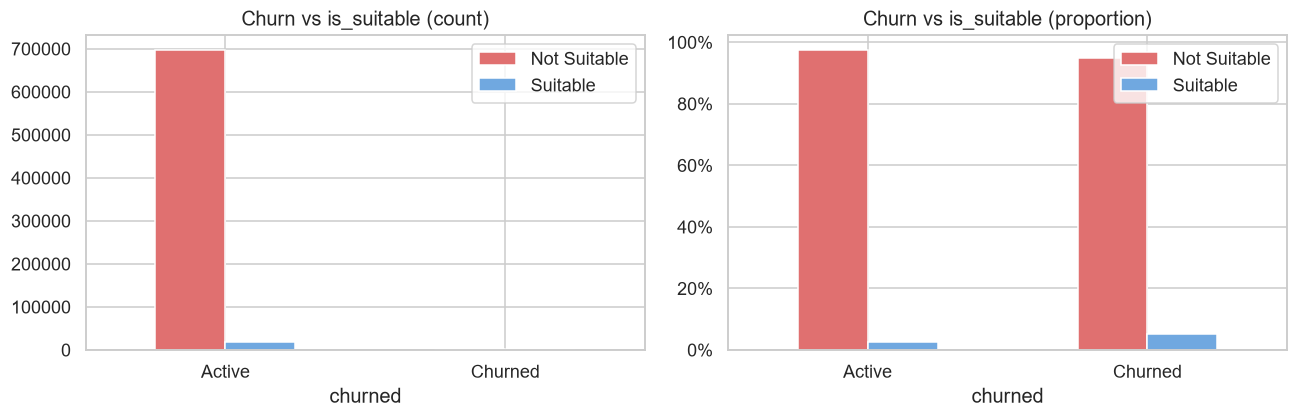

Top 10 churn reasons:
churn_reason
18.0    4482
15.0    2033
11.0    1730
14.0    1553
13.0     778
12.0     548
16.0     535
10.0     317
3.0      170
9.0      106
Name: count, dtype: int64


In [16]:
ct_churn = acc.groupby(['churned','is_suitable']).size().unstack(fill_value=0)
ct_churn_pct = ct_churn.div(ct_churn.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ct_churn.plot.bar(ax=axes[0], color=['#e07070','#70a8e0'])
axes[0].set_title('Churn vs is_suitable (count)')
axes[0].set_xticklabels(['Active','Churned'], rotation=0)
axes[0].legend(['Not Suitable','Suitable'])

ct_churn_pct.plot.bar(ax=axes[1], color=['#e07070','#70a8e0'])
axes[1].set_title('Churn vs is_suitable (proportion)')
axes[1].set_xticklabels(['Active','Churned'], rotation=0)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend(['Not Suitable','Suitable'])

plt.tight_layout()
plt.show()

print('Top 10 churn reasons:')
print(acc['churn_reason'].value_counts().head(10))

### 5f. Geography

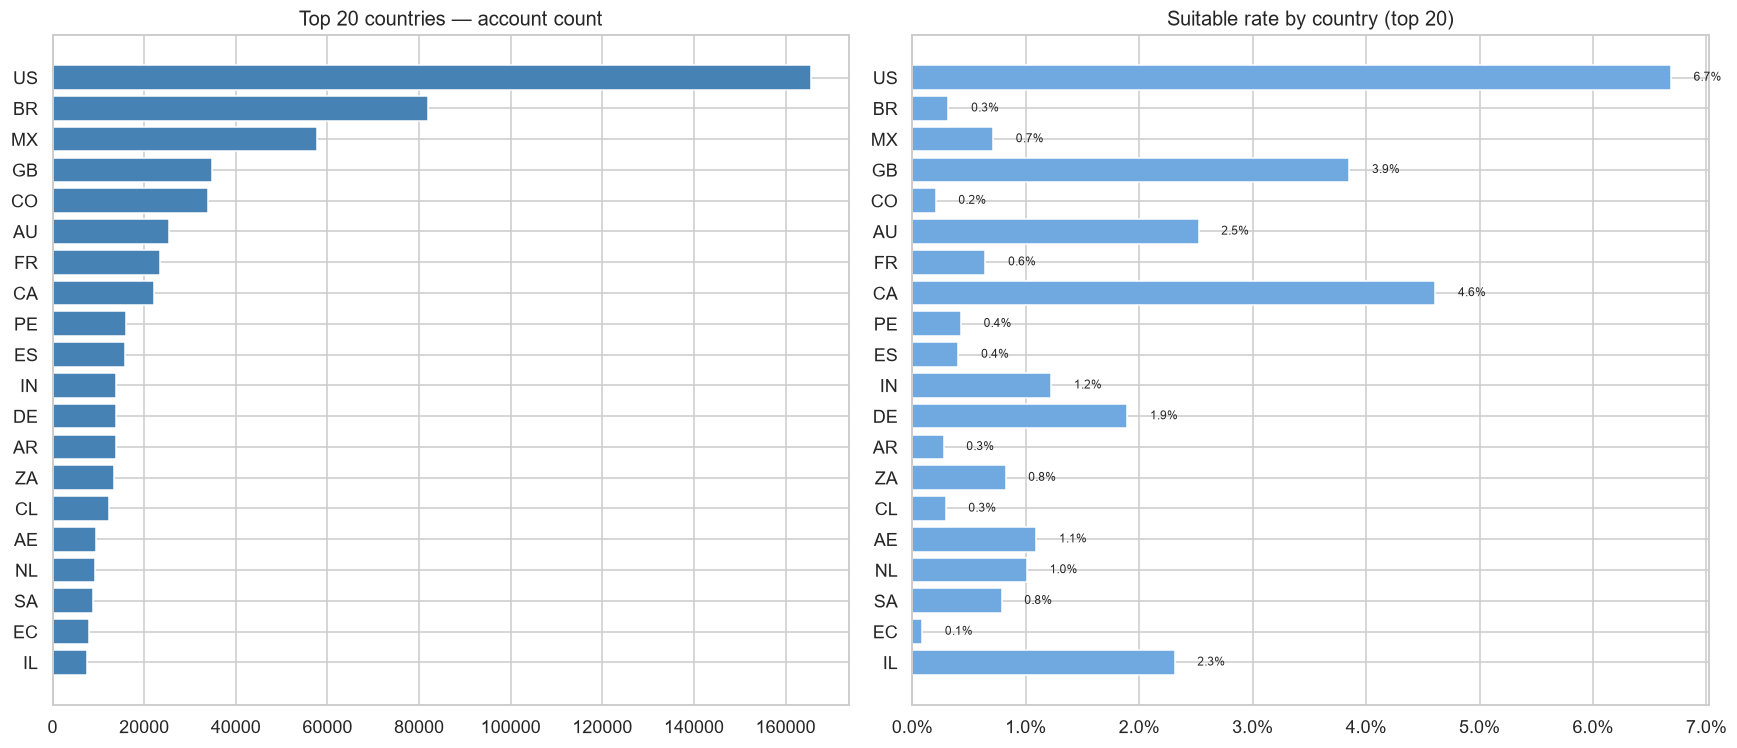

In [17]:
top_countries = acc['country'].value_counts().head(20).index
country_suit  = (
    acc[acc['country'].isin(top_countries)]
    .groupby('country')['is_suitable']
    .agg(['mean','count'])
    .sort_values('count', ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(country_suit.index, country_suit['count'], color='steelblue')
axes[0].set_title('Top 20 countries — account count')

bars = axes[1].barh(country_suit.index, country_suit['mean'], color='#70a8e0')
axes[1].set_title('Suitable rate by country (top 20)')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for bar, v in zip(bars, country_suit['mean']):
    axes[1].text(v + 0.002, bar.get_y() + bar.get_height()/2, f'{v:.1%}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 5g. Device / OS / Browser

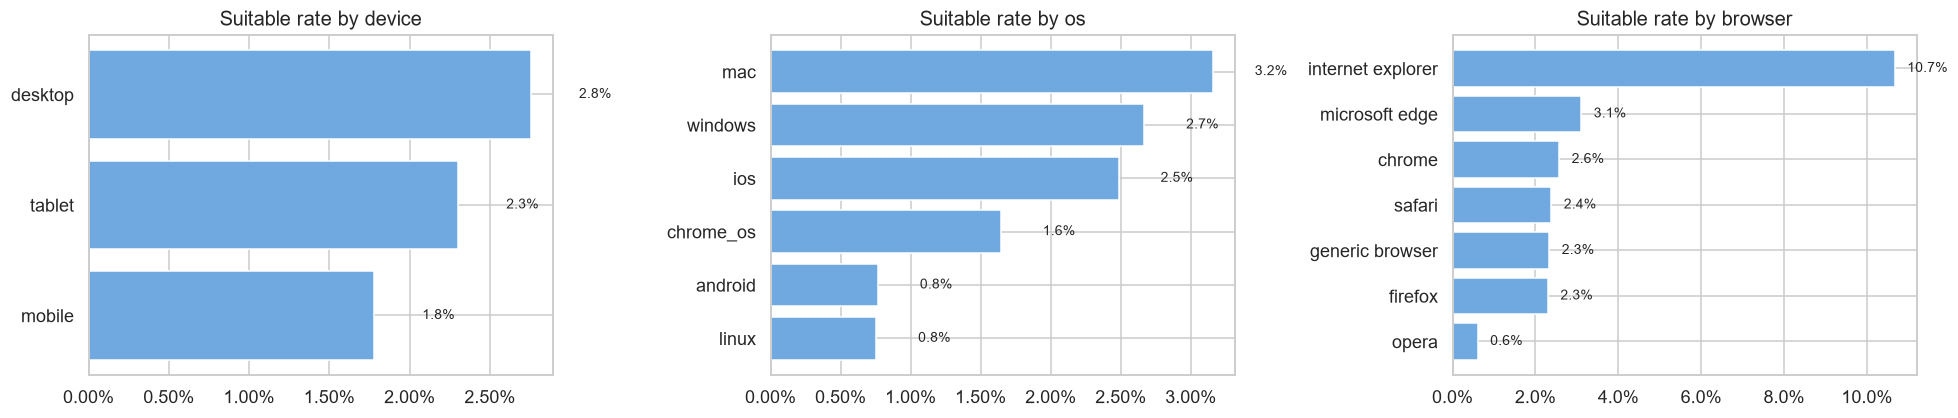

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ['device','os','browser']):
    grp = acc.groupby(col)['is_suitable'].agg(['mean','count'])
    grp = grp[grp['count'] >= 100].sort_values('mean', ascending=True)
    bars = ax.barh(grp.index, grp['mean'], color='#70a8e0')
    ax.set_title(f'Suitable rate by {col}')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    for bar, v in zip(bars, grp['mean']):
        ax.text(v + 0.003, bar.get_y() + bar.get_height()/2, f'{v:.1%}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 5h. Plan ID and User Goal/Description

In [19]:
plan_grp = acc.groupby('plan_id')['is_suitable'].agg(['mean','count'])
plan_grp = plan_grp[plan_grp['count'] >= 50].sort_values('mean', ascending=False)
print('Plan types and suitable rate (top plans, ≥50 accounts):')
print(plan_grp.head(20).to_string())

Plan types and suitable rate (top plans, ≥50 accounts):
             mean  count
plan_id                 
248.0    0.603448     58
244.0    0.245810    179
243.0    0.234568     81
240.0    0.232639    288
239.0    0.195402    174
212.0    0.171429    105
208.0    0.149573    234
211.0    0.148148     54
236.0    0.139045    712
1670.0   0.131783    129
1674.0   0.131429    175
232.0    0.110616   1347
204.0    0.110112    445
235.0    0.108333    720
203.0    0.101896    422
207.0    0.093750     96
1673.0   0.093366    407
234.0    0.089820    167
200.0    0.088825    698
1669.0   0.080000    250


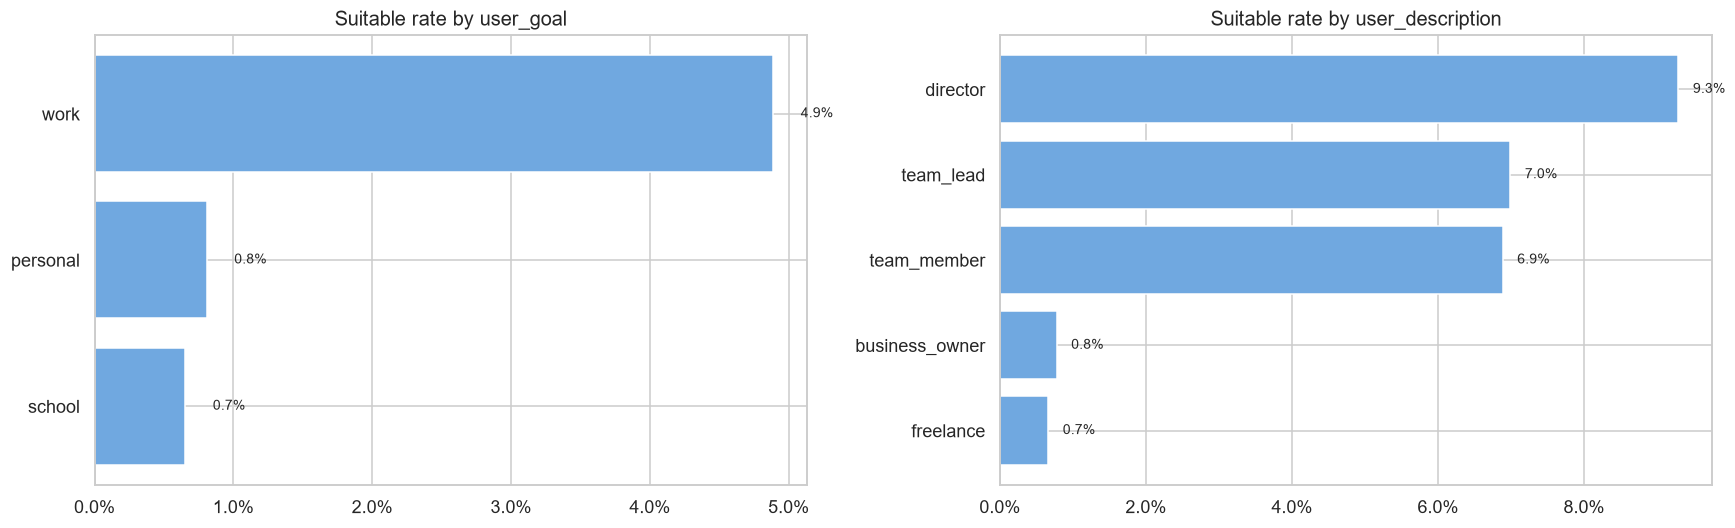

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col in zip(axes, ['user_goal','user_description']):
    grp = acc.groupby(col)['is_suitable'].agg(['mean','count'])
    grp = grp[grp['count'] >= 30].sort_values('mean', ascending=True)
    bars = ax.barh(grp.index, grp['mean'], color='#70a8e0')
    ax.set_title(f'Suitable rate by {col}')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    for bar, v in zip(bars, grp['mean']):
        ax.text(v + 0.002, bar.get_y() + bar.get_height()/2, f'{v:.1%}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. User-Level Features (Aggregated to Account)

### 6a. Team Size (Users per Account)

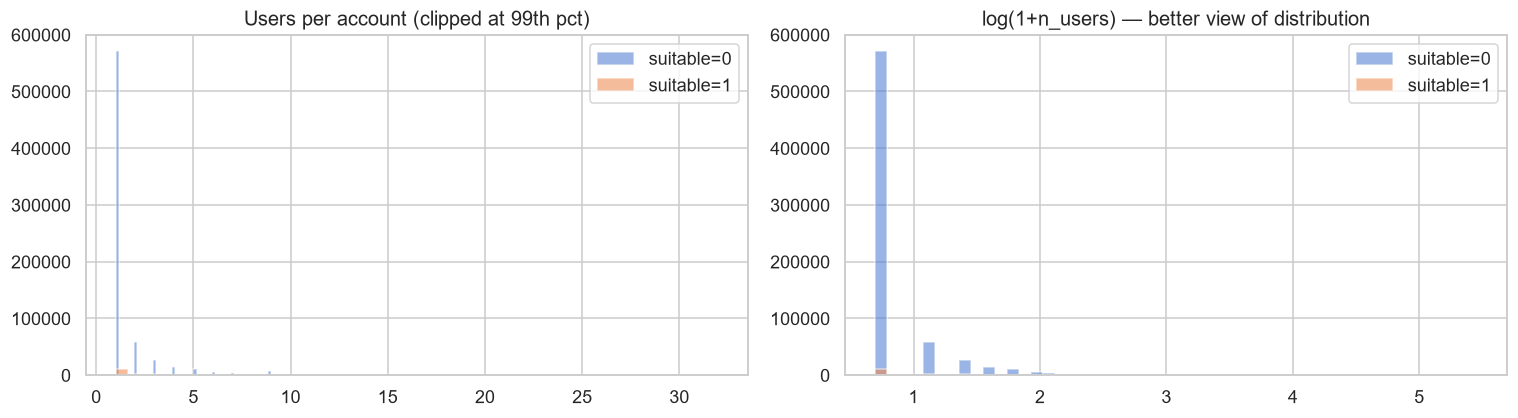

                count  mean  std  min  25%  50%  75%    max
is_suitable                                                
0            698348.0   1.5  2.5  1.0  1.0  1.0  1.0  232.0
1             17753.0   3.2  7.5  1.0  1.0  1.0  3.0  234.0


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, grp in master.dropna(subset=['n_users','is_suitable']).groupby('is_suitable'):
    data = grp['n_users'].clip(upper=grp['n_users'].quantile(0.99))
    axes[0].hist(data, bins=50, alpha=0.55, label=f'suitable={int(label)}')
axes[0].set_title('Users per account (clipped at 99th pct)')
axes[0].legend()

for label, grp in master.dropna(subset=['n_users','is_suitable']).groupby('is_suitable'):
    axes[1].hist(np.log1p(grp['n_users']), bins=50, alpha=0.55, label=f'suitable={int(label)}')
axes[1].set_title('log(1+n_users) — better view of distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print(master.groupby('is_suitable')['n_users'].describe().round(1))

### 6b. Admin / Pending / Enabled Ratios

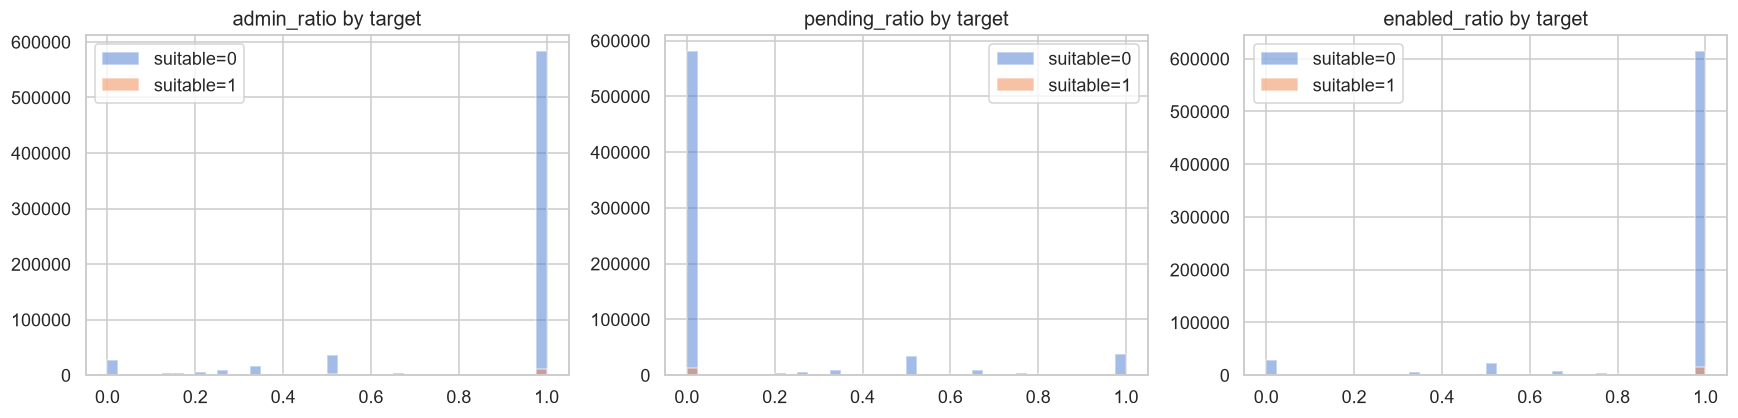

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['admin_ratio','pending_ratio','enabled_ratio']):
    for label, grp in master.dropna(subset=[col,'is_suitable']).groupby('is_suitable'):
        ax.hist(grp[col].dropna(), bins=40, alpha=0.5, label=f'suitable={int(label)}')
    ax.set_title(f'{col} by target')
    ax.legend()
plt.tight_layout()
plt.show()

### 6c. Seniority

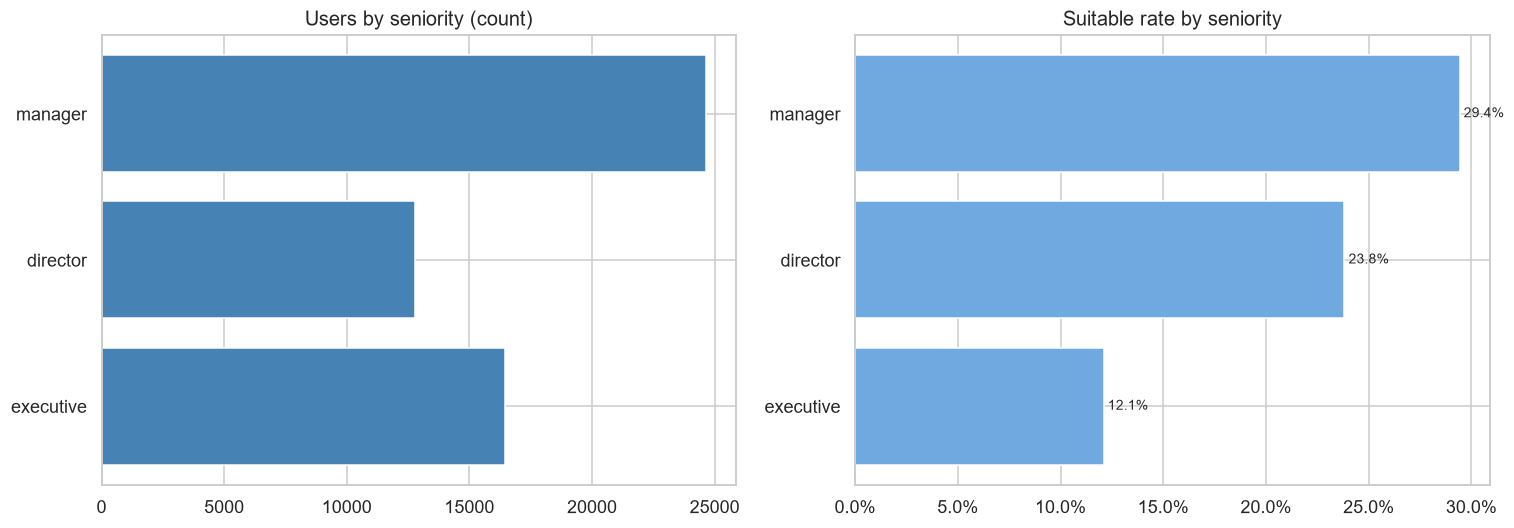

In [23]:
usr_with_target = usr.merge(acc[['account_id','is_suitable']], on='account_id', how='left')
seniority_suit  = usr_with_target.groupby('seniority')['is_suitable'].agg(['mean','count'])
seniority_suit  = seniority_suit[seniority_suit['count'] >= 50].sort_values('mean', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(seniority_suit.index, seniority_suit['count'], color='steelblue')
axes[0].set_title('Users by seniority (count)')

bars = axes[1].barh(seniority_suit.index, seniority_suit['mean'], color='#70a8e0')
axes[1].set_title('Suitable rate by seniority')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for bar, v in zip(bars, seniority_suit['mean']):
    axes[1].text(v + 0.002, bar.get_y() + bar.get_height()/2, f'{v:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 6d. Admin Time-to-Activation

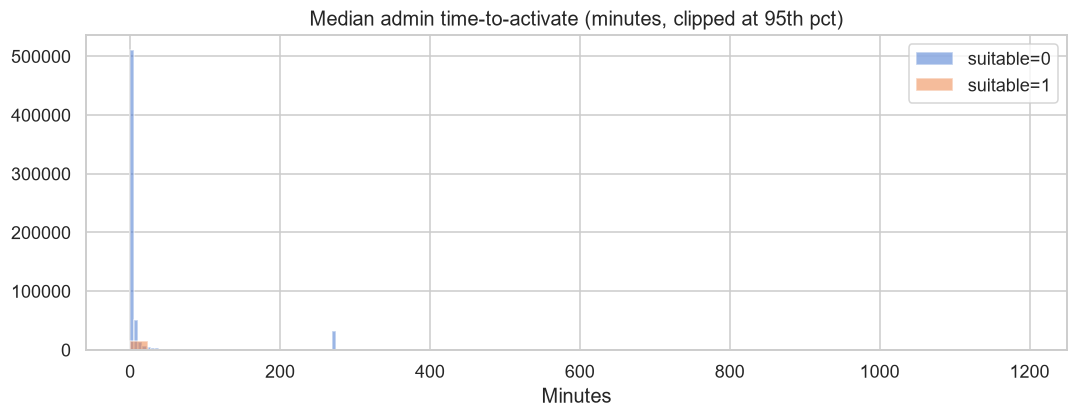

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, grp in master.dropna(subset=['median_admin_tta_min','is_suitable']).groupby('is_suitable'):
    data = grp['median_admin_tta_min'].clip(0, grp['median_admin_tta_min'].quantile(0.95))
    ax.hist(data, bins=50, alpha=0.55, label=f'suitable={int(label)}')
ax.set_title('Median admin time-to-activate (minutes, clipped at 95th pct)')
ax.set_xlabel('Minutes')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Event-Level Usage Patterns

In [25]:
print(f'Accounts with at least 1 event: {master["total_events"].notna().sum():,} / {len(master):,}')
print(f'\nMedian events by suitability:')
print(master.groupby('is_suitable')[['total_events','active_days','active_users']].median())

Accounts with at least 1 event: 716,630 / 716,830

Median events by suitability:
             total_events  active_days  active_users
is_suitable                                         
0                   150.0          9.0           3.0
1                   359.0         12.0           4.0


### 7a. Total Events & Active Days

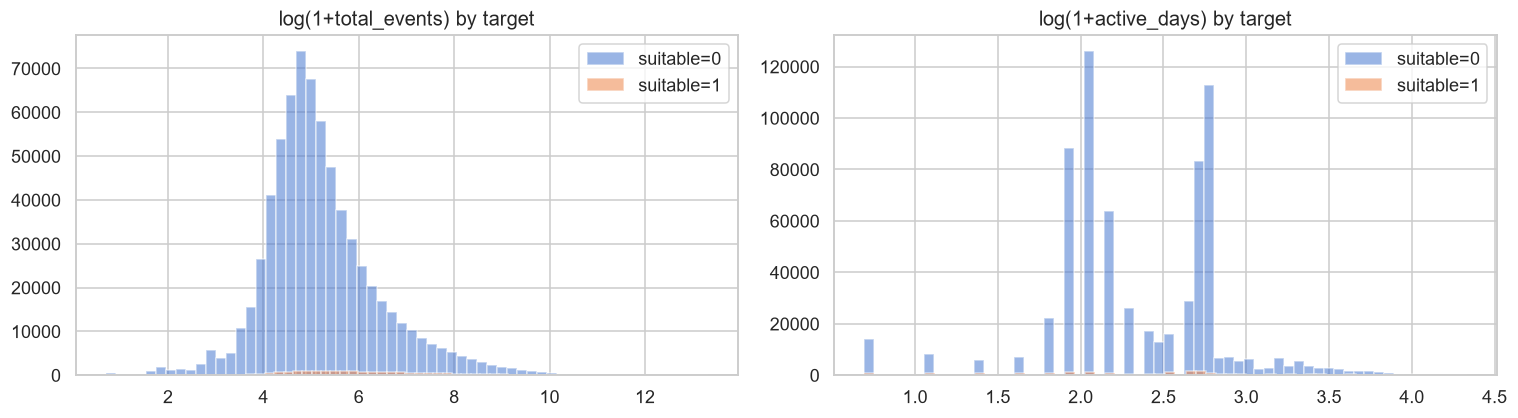

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for col, ax in zip(['total_events','active_days'], axes):
    for label, grp in master.dropna(subset=[col,'is_suitable']).groupby('is_suitable'):
        ax.hist(np.log1p(grp[col]), bins=60, alpha=0.55, label=f'suitable={int(label)}')
    ax.set_title(f'log(1+{col}) by target')
    ax.legend()
plt.tight_layout()
plt.show()

### 7b. Event Type Mix — Suitable vs Not

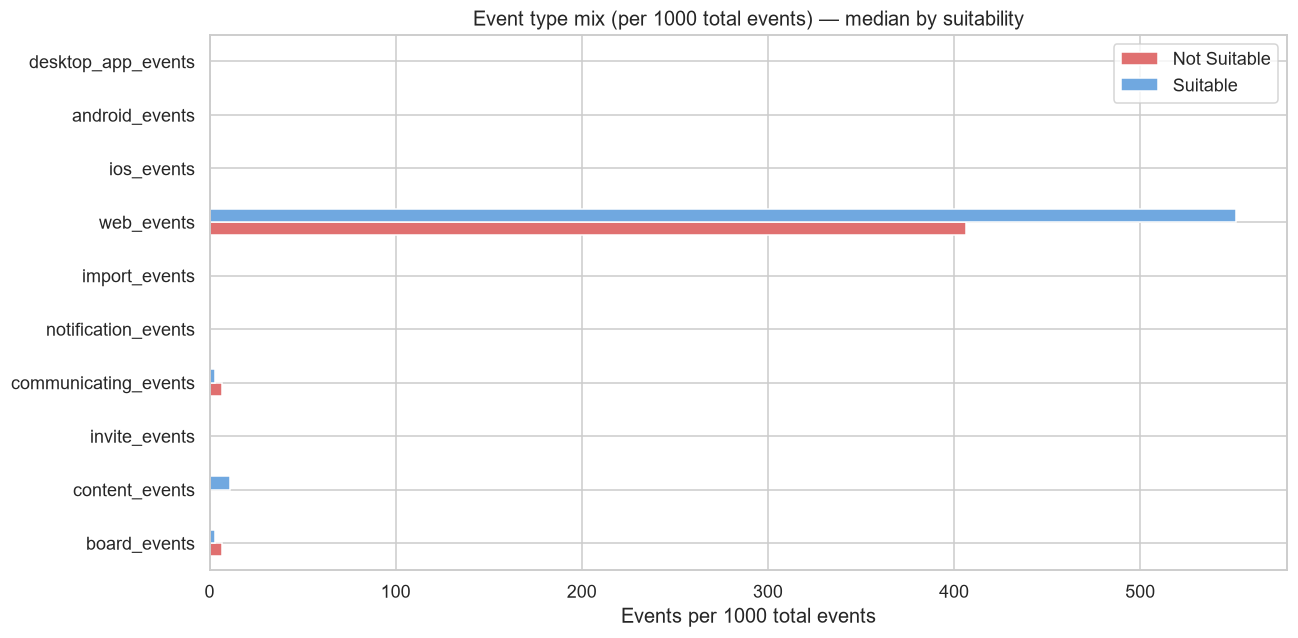

In [27]:
event_cols = [
    'board_events','content_events','invite_events','communicating_events',
    'notification_events','import_events','web_events','ios_events',
    'android_events','desktop_app_events'
]

medians = (
    master.dropna(subset=['is_suitable'])
    .groupby('is_suitable')[event_cols]
    .median().T
)
totals = master.dropna(subset=['is_suitable']).groupby('is_suitable')['total_events'].median()
medians_normed = medians.div(totals) * 1000

medians_normed.plot.barh(figsize=(12, 6), color=['#e07070','#70a8e0'])
plt.title('Event type mix (per 1000 total events) — median by suitability')
plt.xlabel('Events per 1000 total events')
plt.legend(['Not Suitable','Suitable'])
plt.tight_layout()
plt.show()

### 7c. Platform Usage Share

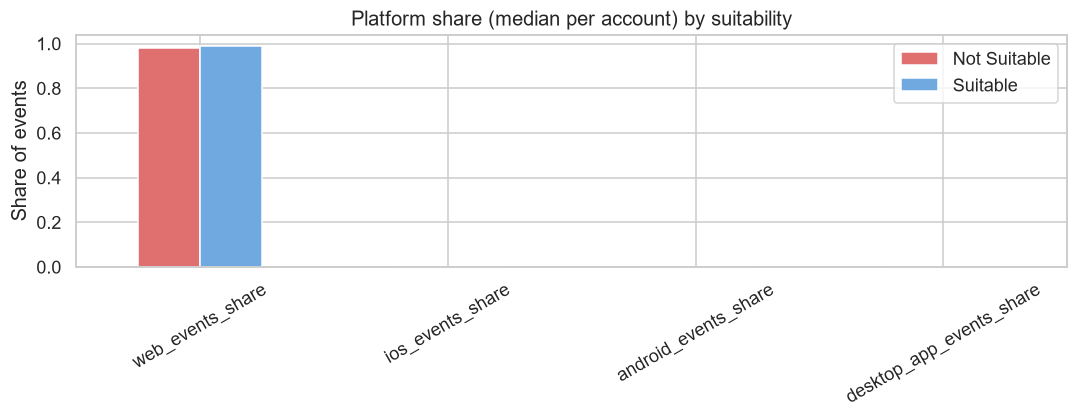

In [28]:
share_cols = ['web_events_share','ios_events_share','android_events_share','desktop_app_events_share']
medians_share = master.dropna(subset=['is_suitable']).groupby('is_suitable')[share_cols].median().T

medians_share.plot.bar(figsize=(10, 4), color=['#e07070','#70a8e0'])
plt.title('Platform share (median per account) by suitability')
plt.ylabel('Share of events')
plt.xticks(rotation=30)
plt.legend(['Not Suitable','Suitable'])
plt.tight_layout()
plt.show()

### 7d. Derived Engagement Features

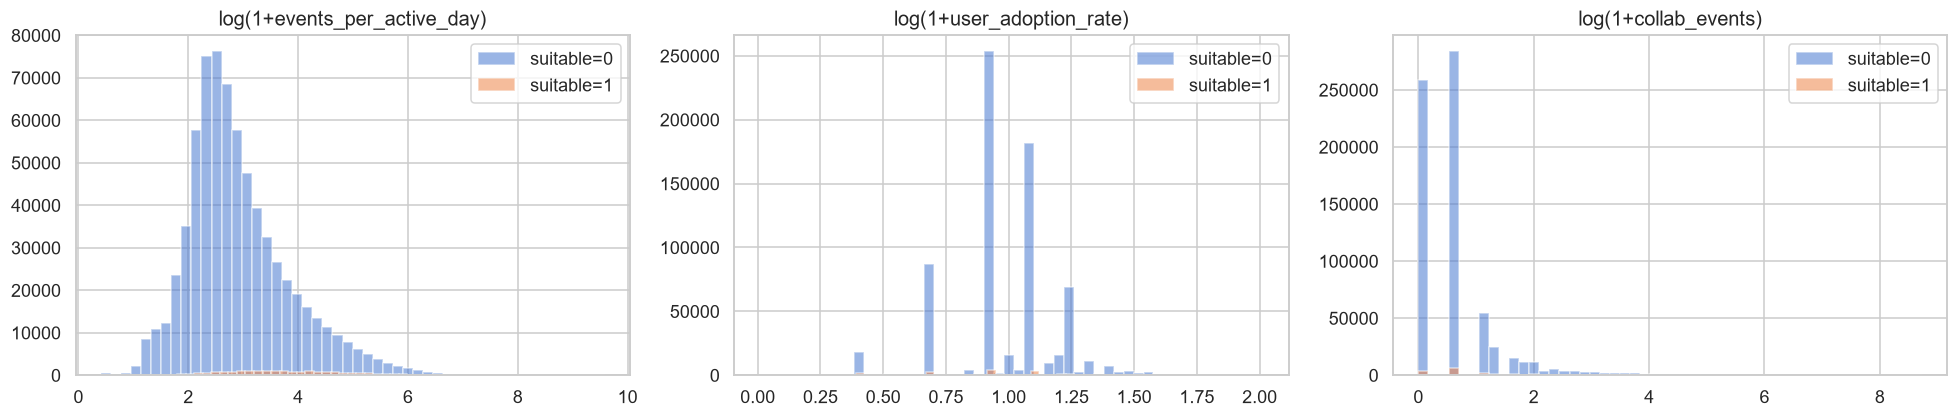

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ['events_per_active_day','user_adoption_rate','collab_events']):
    for label, grp in master.dropna(subset=[col,'is_suitable']).groupby('is_suitable'):
        data = np.log1p(grp[col])
        ax.hist(data, bins=50, alpha=0.55, label=f'suitable={int(label)}')
    ax.set_title(f'log(1+{col})')
    ax.legend()
plt.tight_layout()
plt.show()

## 8. Temporal Patterns

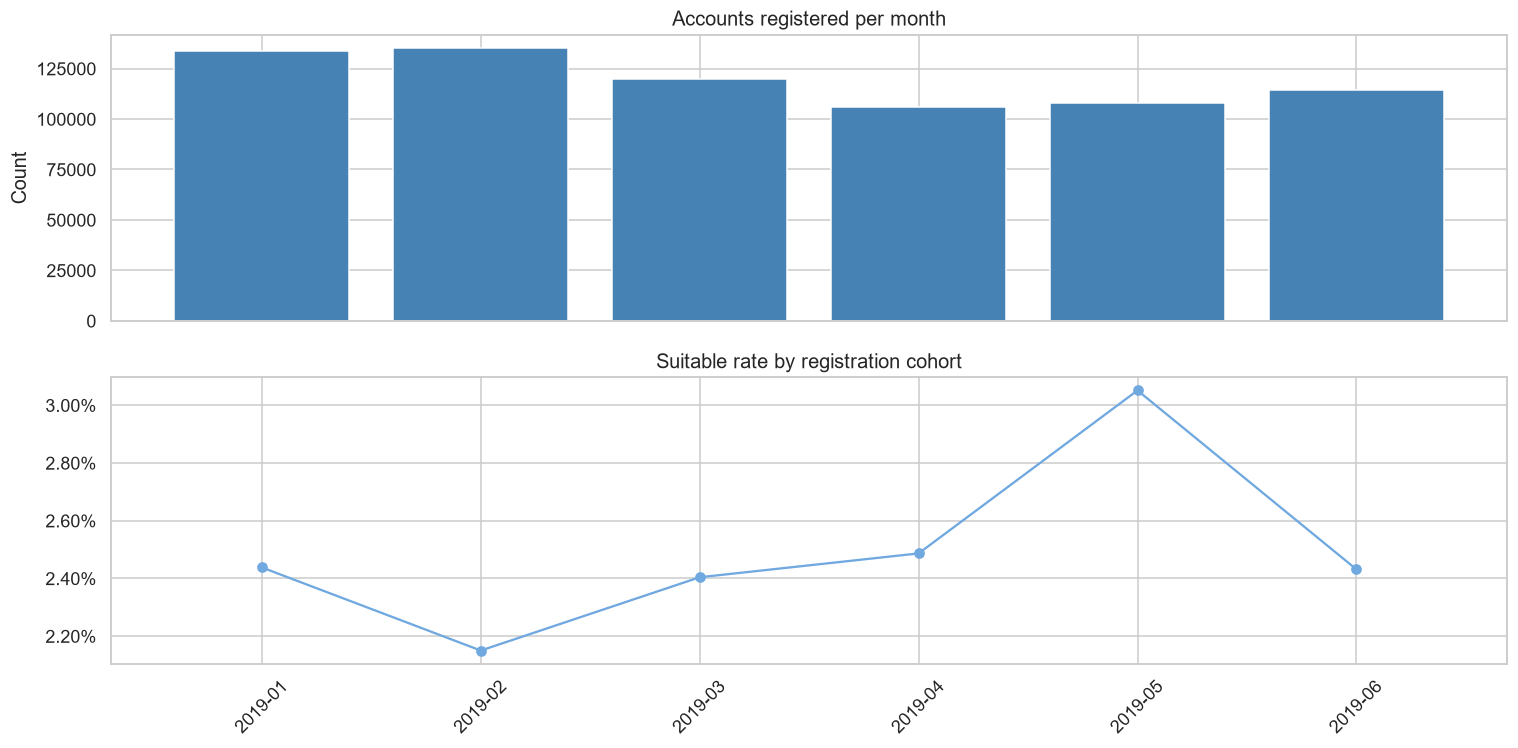

In [30]:
cohort_suit = acc.groupby('cohort_month')['is_suitable'].agg(['mean','count'])
cohort_suit = cohort_suit[cohort_suit['count'] >= 30]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].bar(cohort_suit.index.astype(str), cohort_suit['count'], color='steelblue')
axes[0].set_title('Accounts registered per month')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(cohort_suit.index.astype(str), cohort_suit['mean'], marker='o', color='#70a8e0')
axes[1].set_title('Suitable rate by registration cohort')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

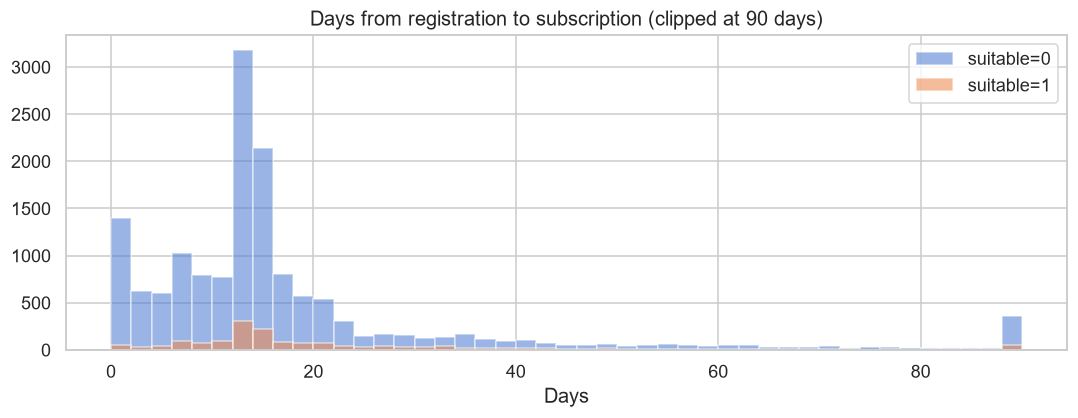

               count  mean   std    min   25%   50%   75%    max
is_suitable                                                     
0            15212.0  18.0  21.5    0.0   8.0  13.0  18.0  213.0
1             1635.0  22.7  24.6 -296.0  12.0  14.0  26.0  210.0


In [31]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, grp in acc.dropna(subset=['days_to_subscription','is_suitable']).groupby('is_suitable'):
    ax.hist(grp['days_to_subscription'].clip(0, 90), bins=45, alpha=0.55, label=f'suitable={int(label)}')
ax.set_title('Days from registration to subscription (clipped at 90 days)')
ax.set_xlabel('Days')
ax.legend()
plt.tight_layout()
plt.show()

print(acc.groupby('is_suitable')['days_to_subscription'].describe().round(1))

## 9. Correlation Heatmap with Target

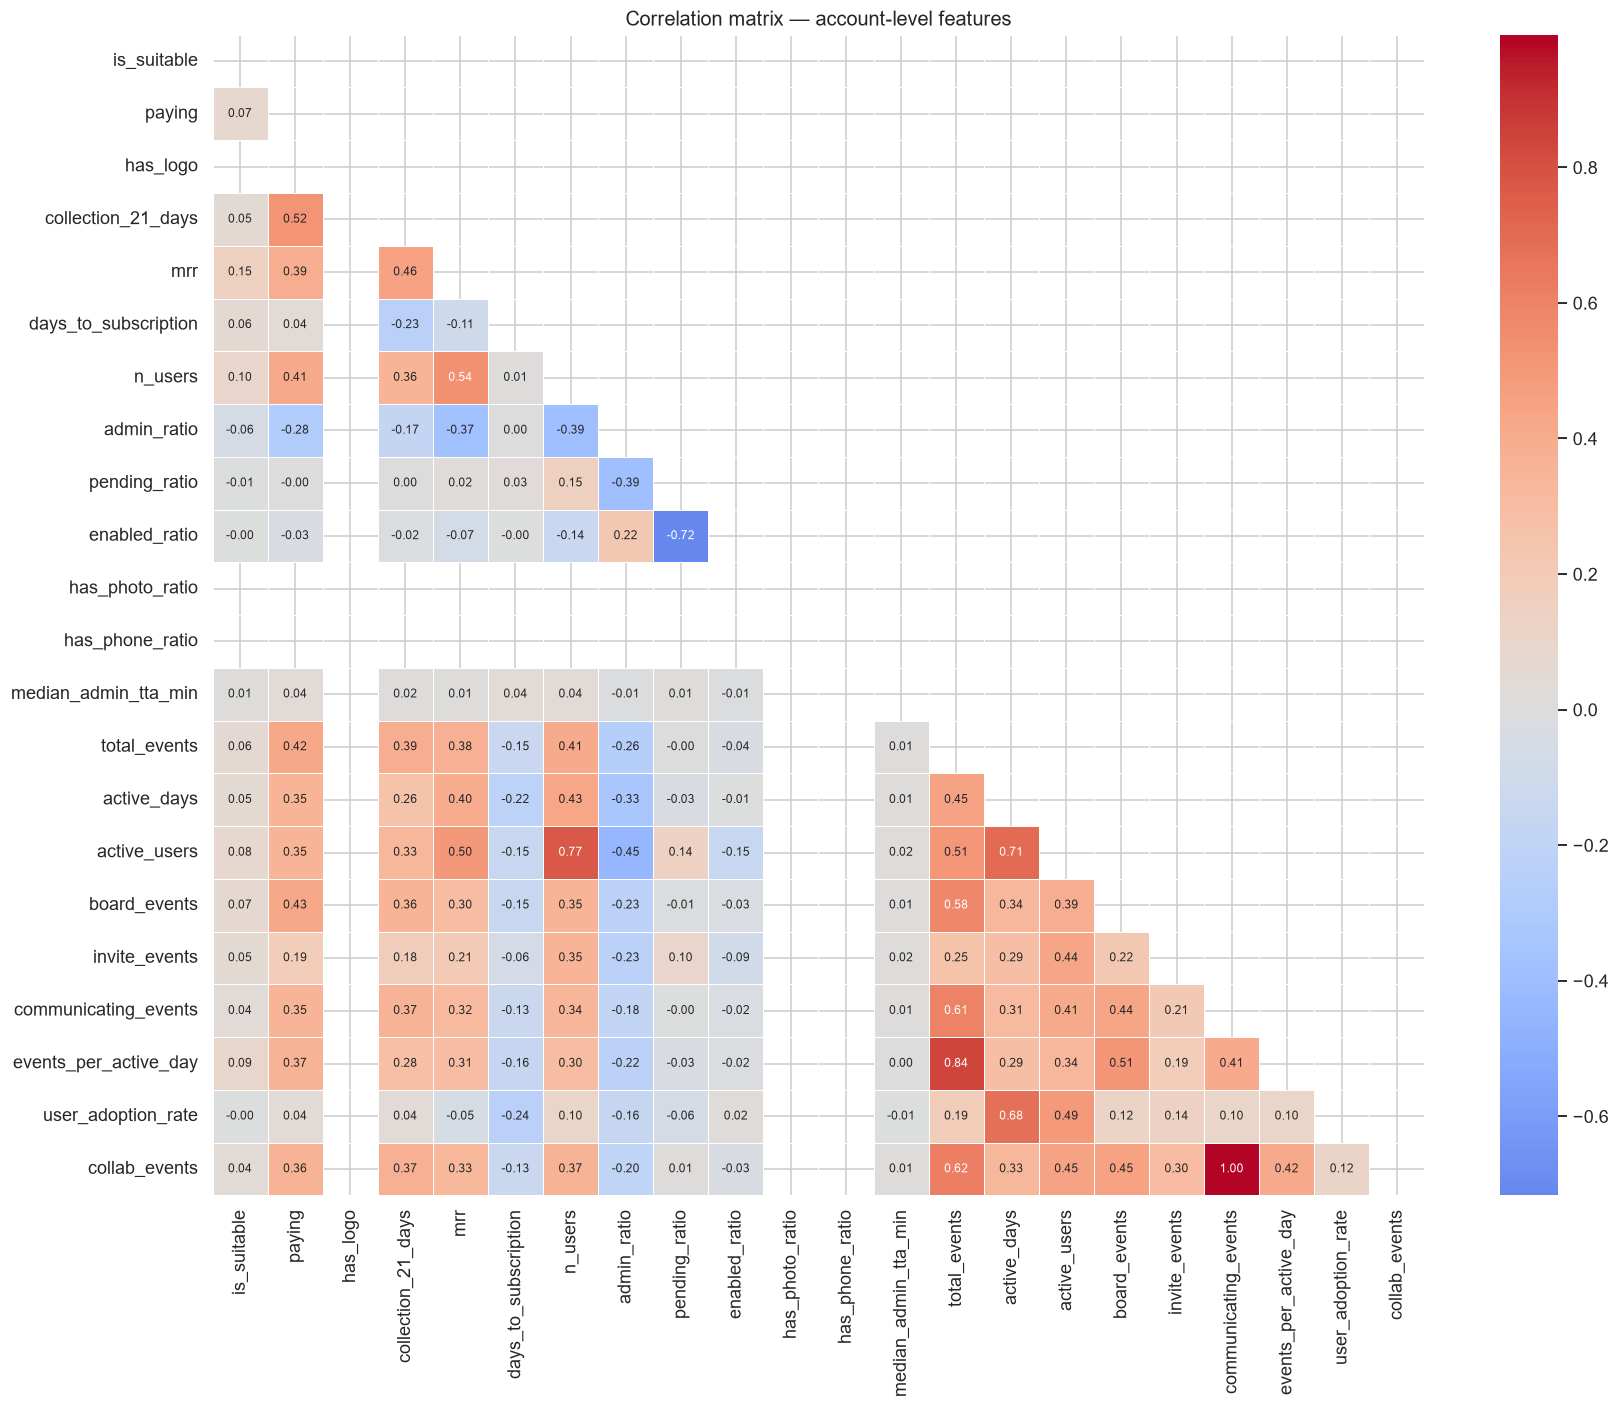


Top features by absolute correlation with is_suitable:
mrr                      0.147227
n_users                  0.095325
events_per_active_day    0.086583
active_users             0.077101
paying                   0.073297
board_events             0.066595
days_to_subscription     0.063941
total_events             0.063735
admin_ratio             -0.061238
collection_21_days       0.050831
invite_events            0.049000
active_days              0.046715
collab_events            0.042282
communicating_events     0.038561
pending_ratio           -0.006478
median_admin_tta_min     0.006154
user_adoption_rate      -0.004583
enabled_ratio           -0.001572
has_logo                      NaN
has_photo_ratio               NaN
has_phone_ratio               NaN


In [32]:
corr_cols = [
    'is_suitable',
    'paying','has_logo','collection_21_days','mrr','days_to_subscription',
    'n_users','admin_ratio','pending_ratio','enabled_ratio',
    'has_photo_ratio','has_phone_ratio','median_admin_tta_min',
    'total_events','active_days','active_users',
    'board_events','invite_events','communicating_events',
    'events_per_active_day','user_adoption_rate','collab_events'
]

corr_df = master[[c for c in corr_cols if c in master.columns]].copy()
for col in corr_df.columns:
    corr_df[col] = pd.to_numeric(corr_df[col], errors='coerce')

corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True, fmt='.2f', mask=mask, cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation matrix — account-level features', fontsize=13)
plt.tight_layout()
plt.show()

print('\nTop features by absolute correlation with is_suitable:')
target_corr = corr['is_suitable'].drop('is_suitable').sort_values(key=abs, ascending=False)
print(target_corr.to_string())

## 10. Key EDA Findings & Feature Engineering Ideas

### Data Quality Issues
| Issue | Detail | Fix |
|---|---|---|
| `team_size` Excel mangling | `02-May` → `2-5`, `06-Oct` → `6-10` | Manual string mapping |
| High missingness | `seniority`, `user_goal`, `language` >30% missing | Explicit `MISSING` category |
| Target leakage risk | `subscription_started_at`, `churn_date`, `mrr` reflect post-registration state | Exclude or use only 14-day window values |
| Sentinel NA strings | Raw CSV uses `'NA'` as string | Replaced with `np.nan` on load |

### Strongest Signals for Predicting `is_suitable`
| Feature | Direction | Notes |
|---|---|---|
| `mrr` | ↑ suitable | Higher revenue accounts need more support |
| `n_users` | ↑ suitable | Larger teams → more consulting value |
| `paying` | ↑ suitable | Paying accounts more likely to invest in consulting |
| `total_events` | ↑ suitable | Active users need guidance to deepen usage |
| `invite_events` | ↑ suitable | Inviting teammates = growth intent |
| `active_days` | ↑ suitable | Consistency beats volume |
| `industry` | varies | Software/tech/construction verticals show higher rates |
| `company_size` | ↑ suitable | Larger orgs have more complex onboarding needs |
| `days_to_subscription` | ↓ suitable | Faster paid conversion = better product fit |

### Feature Engineering Plan
1. **Engagement intensity**: `events_per_active_day` (already built)
2. **User adoption**: `user_adoption_rate = active_users / n_users` (already built)
3. **Collaboration signal**: `collab_events = invite + communicating` (already built)
4. **Board depth**: `count_kind_columns / (num_of_boards + 1)` — richness of board usage
5. **Platform entropy**: Shannon entropy of platform event shares
6. **Admin activation speed**: `median_admin_tta_min` — how quickly key users engage
7. **Profile completeness**: `has_photo_ratio`, `has_phone_ratio`, `has_logo`
8. **Country encoding**: target-encode country, region (smoothed to avoid leakage)
9. **Time features**: account registration day-of-week, week-of-year

### Business Segments (Hypotheses to Validate)
1. **Enterprise power users**: Large team (`>25`) + high `total_events` + paying → highest consulting ROI
2. **Engaged SMBs**: Small team but high `invite_events` + multiple active days → growth mindset, consulting scales them
3. **High-value verticals**: Software / IT / construction industries → consistently above-average suitable rates

### Class Imbalance Note
- If `is_suitable=1` is a minority class (likely <30%), use:
  - `class_weight='balanced'` in tree models
  - Threshold tuning (optimize F1 or recall @ precision constraint)
  - Evaluation metric: **PR-AUC** and **F1** over accuracy

In [33]:
print('=== Master dataframe summary ===')
print(f'Shape: {master.shape}')
print(f'\nTarget distribution:')
print(master['is_suitable'].value_counts(dropna=False))
print(f'\nColumns:')
for c in sorted(master.columns):
    dtype = master[c].dtype
    null_pct = master[c].isnull().mean()
    print(f'  {c:<35} {str(dtype):<12} {null_pct:.1%} missing')

=== Master dataframe summary ===
Shape: (716830, 69)

Target distribution:
is_suitable
0    699077
1     17753
Name: count, dtype: int64

Columns:
  account_id                          int64        0.0% missing
  account_name                        str          0.0% missing
  active_days                         float64      0.0% missing
  active_users                        float64      0.0% missing
  admin_ratio                         float64      0.1% missing
  android_events                      float64      0.0% missing
  android_events_share                float64      0.0% missing
  board_events                        float64      0.0% missing
  browser                             str          14.1% missing
  churn_date                          datetime64[us] 99.8% missing
  churn_reason                        float64      98.3% missing
  churned                             int64        0.0% missing
  cohort_month                        period[M]    0.0% missing
  collab_events 